# EDA - Phát hiện dữ liệu khuyết

Notebook này là điểm vào cho phần kiểm tra missing value. Logic chính nằm trong `EDA/src/03_detect_missing_values.py` để có thể chạy lại ổn định bằng script.

In [1]:
from pathlib import Path
import subprocess
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parents[1]
elif not (ROOT / "EDA").exists():
    ROOT = ROOT.parents[0]

SCRIPT = ROOT / "EDA" / "src" / "03_detect_missing_values.py"
REPORT = ROOT / "EDA" / "docs" / "03-missing-values" / "03_missing_values_report.md"
FIGURE_DIR = ROOT / "EDA" / "outputs" / "figures" / "03_missing_values"
TABLE_DIR = ROOT / "EDA" / "outputs" / "tables" / "03_missing_values"

ROOT

WindowsPath('d:/Tài liệu Bách khoa/DataWarehouse/BTN')

## Chạy lại kiểm tra missing value

In [2]:
subprocess.run([sys.executable, str(SCRIPT)], cwd=ROOT, check=True)

CompletedProcess(args=['d:\\Tài liệu Bách khoa\\DataWarehouse\\BTN\\.venv\\Scripts\\python.exe', 'd:\\Tài liệu Bách khoa\\DataWarehouse\\BTN\\EDA\\src\\03_detect_missing_values.py'], returncode=0)

## Report

In [3]:
from IPython.display import Markdown, display

display(Markdown(REPORT.read_text(encoding="utf-8")))

# Báo Cáo EDA - Phát Hiện Dữ Liệu Khuyết

## 1. Phạm vi

Phần này kiểm tra missing value trong các bảng staging và các bảng EDA-ready. Kết quả không tự động xóa hay điền dữ liệu thiếu. Mục tiêu là xác định missing nào có ý nghĩa nghiệp vụ và missing nào cần xử lý rõ ở bước phân tích sau.

## 2. Nhận xét chính

- Bảng có tỷ lệ missing trên toàn bộ ô dữ liệu cao nhất là `stg_vle` với 27.5%.
- `date_unregistration` thiếu 22,521 trên 32,593 dòng. Đây chủ yếu là missing hợp lệ, vì sinh viên không hủy đăng ký thường không có ngày hủy.
- Trong nhóm `Withdrawn`, có 93 dòng thiếu `date_unregistration`. Nhóm này cần kiểm tra riêng nếu dùng ngày hủy đăng ký.
- `score` thiếu 173 trên 173,912 dòng assessment đã quan sát, chiếm 0.1%.
- `date_submitted` thiếu 0 dòng trong các bảng submission đang có.
- `imd_band` thiếu 1,111 dòng, chiếm 3.4% trong `studentInfo`.

Đọc diễn giải chi tiết tại [03_missing_values_insights.md](03_missing_values_insights.md).

## 3. Phân loại missing value

Các trường cần chú ý mức trung bình:

- `stg_vle.week_from`: 5,243 missing. Giữ nguyên ở EDA; kiểm tra lại nếu dùng cột này làm mốc thời gian.
- `stg_vle.week_to`: 5,243 missing. Giữ nguyên ở EDA; kiểm tra lại nếu dùng cột này làm mốc thời gian.
- `stg_student_registration.date_unregistration`: 22,521 missing. Diễn giải là không hủy đăng ký; kiểm tra riêng các dòng Withdrawn bị thiếu ngày hủy.
- `eda_student_summary.weighted_score`: 9,087 missing. Không thay bằng 0 nếu 0 có nghĩa điểm thật; dùng flag hoặc phân nhóm no_submission.
- `eda_student_summary.avg_score`: 6,773 missing. Giữ NaN và dùng kèm submitted_assessments/submitted_records khi phân tích.
- `stg_assessments.date`: 11 missing. Giữ nguyên ở EDA; kiểm tra lại nếu dùng cột này làm mốc thời gian.
- `stg_student_info.imd_band`: 1,111 missing. Giữ nhóm Unknown hoặc tạo flag is_missing_imd_band khi dùng trong phân tích/model.
- `eda_assessment_progress.score`: 173 missing. Tạo flag is_missing_score; không xóa tự động vì có thể liên quan tới bài chưa chấm hoặc bản ghi banked.

Diễn giải quan trọng:

- Không nên xóa dòng chỉ vì `date_unregistration` bị thiếu.
- Không nên thay `score`, `avg_score` hoặc `weighted_score` bị thiếu bằng 0 nếu 0 có thể là điểm thật.
- Với biến nền như `imd_band`, nên giữ nhóm `Unknown` hoặc tạo flag missing khi dùng cho phân tích/model.
- `date_submitted` không bị thiếu trong các submission quan sát được. Việc chưa nộp bài không được biểu diễn bằng một dòng có `date_submitted` rỗng, mà thường là không có bản ghi submission tương ứng.

## 4. Bảng đầu ra

- `EDA/outputs/tables/03_missing_values/background_missing_summary.csv`
- `EDA/outputs/tables/03_missing_values/date_submitted_missing_summary.csv`
- `EDA/outputs/tables/03_missing_values/date_unregistration_missing_by_final_result.csv`
- `EDA/outputs/tables/03_missing_values/missing_by_column.csv`
- `EDA/outputs/tables/03_missing_values/missing_by_table.csv`
- `EDA/outputs/tables/03_missing_values/missing_classification.csv`
- `EDA/outputs/tables/03_missing_values/score_missing_by_assessment_type.csv`
- `EDA/outputs/tables/03_missing_values/score_missing_by_banked.csv`

## 5. Biểu đồ đầu ra

- `EDA/outputs/figures/03_missing_values/background_missing_rates.png`
- `EDA/outputs/figures/03_missing_values/date_unregistration_missing_by_final_result.png`
- `EDA/outputs/figures/03_missing_values/date_unregistration_missing_heatmap.png`
- `EDA/outputs/figures/03_missing_values/missing_matrix_heatmap.png`
- `EDA/outputs/figures/03_missing_values/missing_rate_by_table.png`
- `EDA/outputs/figures/03_missing_values/score_missing_by_assessment_type.png`
- `EDA/outputs/figures/03_missing_values/top_missing_columns.png`

## 6. Khuyến nghị xử lý

- Giữ nguyên missing có ý nghĩa nghiệp vụ và ghi rõ cách diễn giải.
- Tạo flag như `is_unregistered`, `is_missing_score`, `is_missing_imd_band` nếu các biến này được dùng trong phân tích sâu hơn.
- Khi phân tích điểm, luôn đi kèm số bài đã nộp hoặc số assessment có điểm để tránh hiểu nhầm sinh viên không có điểm với sinh viên điểm 0.
- Nếu nhóm chọn bài toán cảnh báo sớm, cần phân biệt dữ liệu vắng mặt do chưa phát sinh ở thời điểm checkpoint với dữ liệu thật sự thiếu.


## Bảng và biểu đồ đã sinh

In [4]:
import pandas as pd

pd.DataFrame({"table": sorted(path.name for path in TABLE_DIR.glob("*.csv"))})

,table
0,background_missing_summary.csv
1,date_submitted_missing_summary.csv
2,date_unregistration_missing_by_final_result.csv
3,missing_by_column.csv
4,missing_by_table.csv
5,missing_classification.csv
6,score_missing_by_assessment_type.csv
7,score_missing_by_banked.csv


background_missing_rates.png


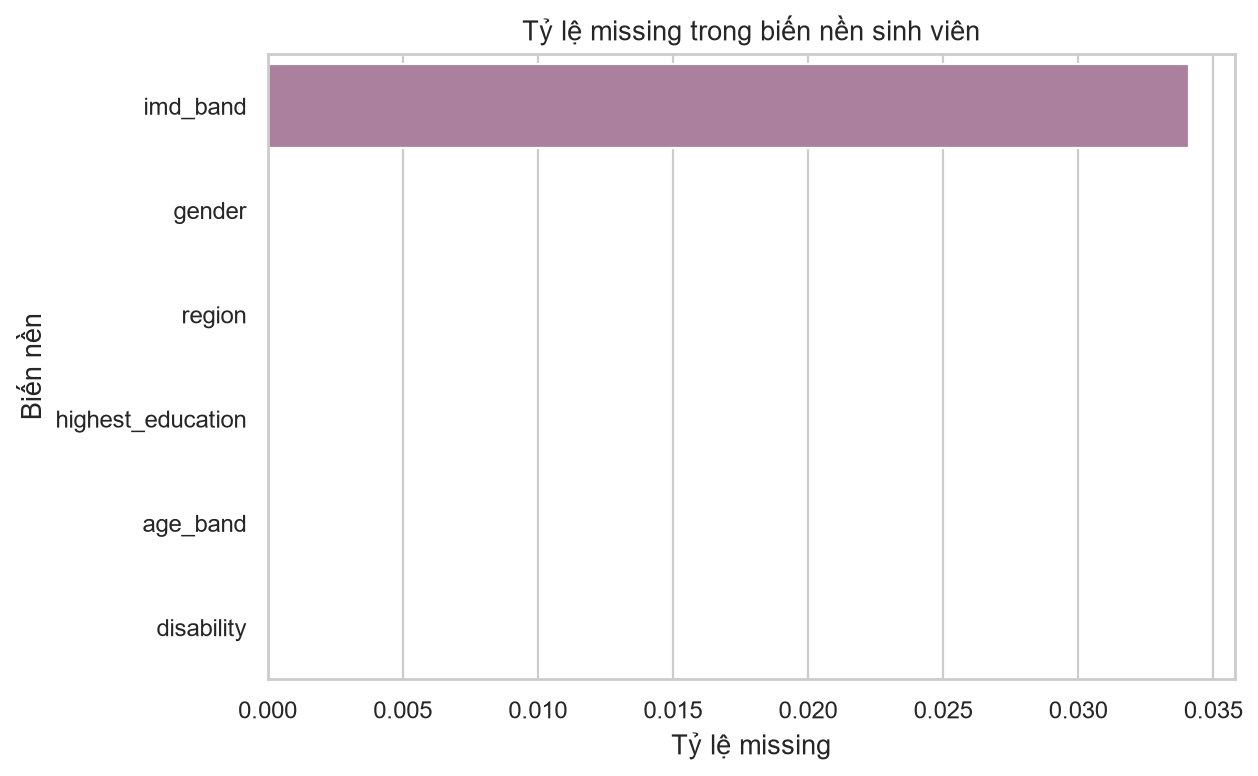

date_unregistration_missing_by_final_result.png


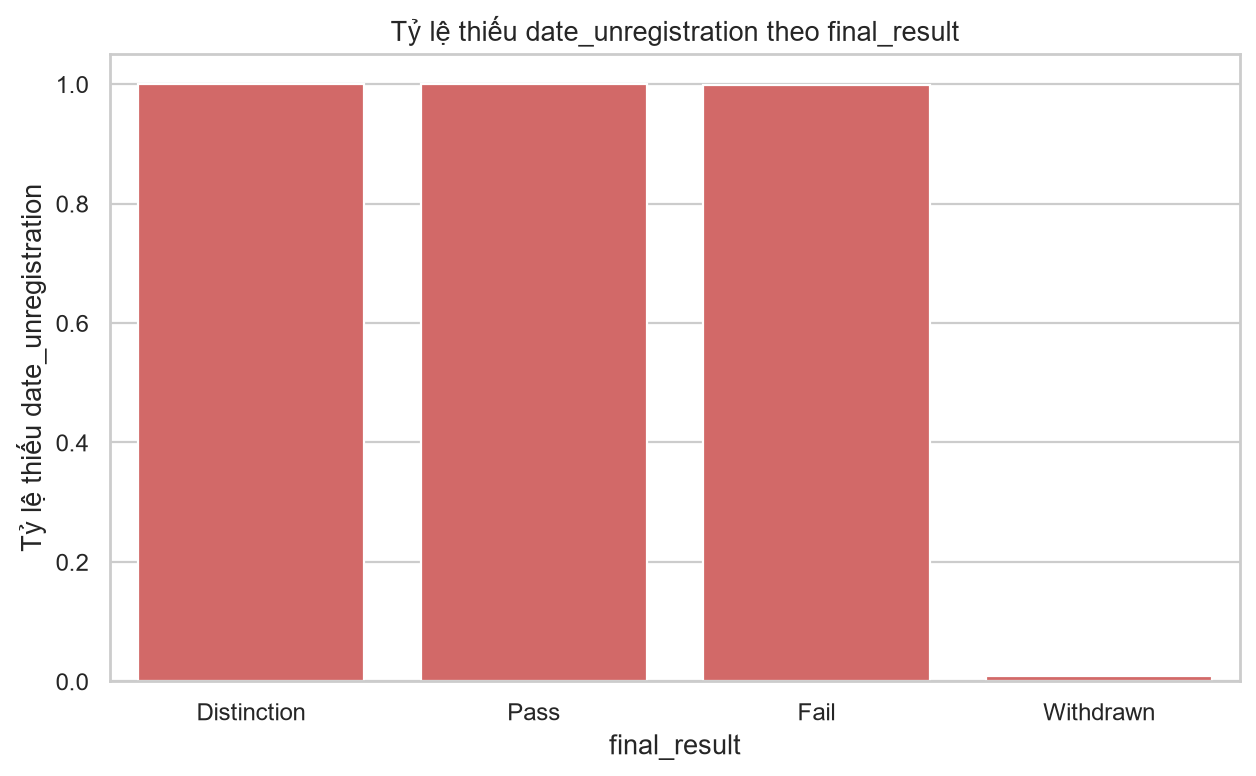

date_unregistration_missing_heatmap.png


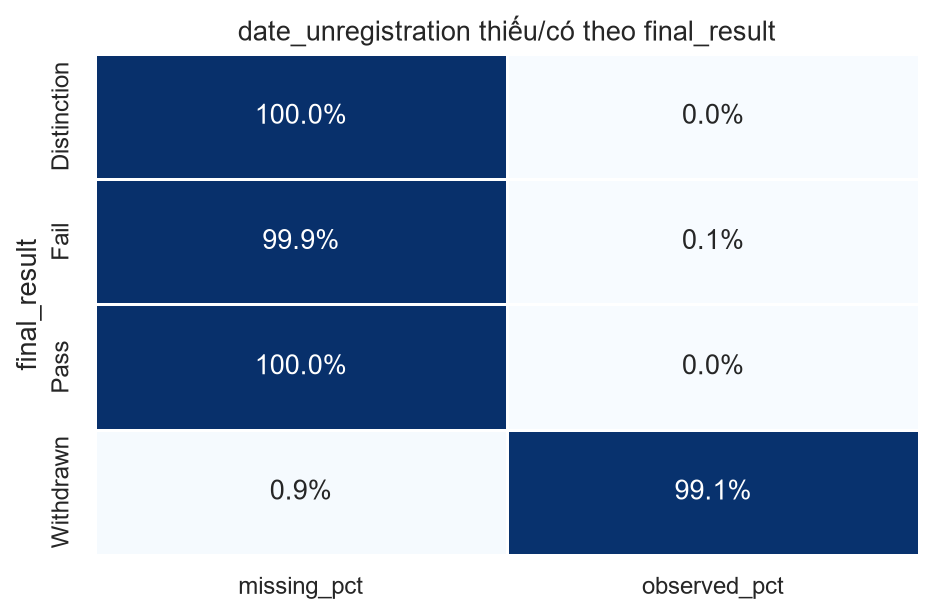

missing_matrix_heatmap.png


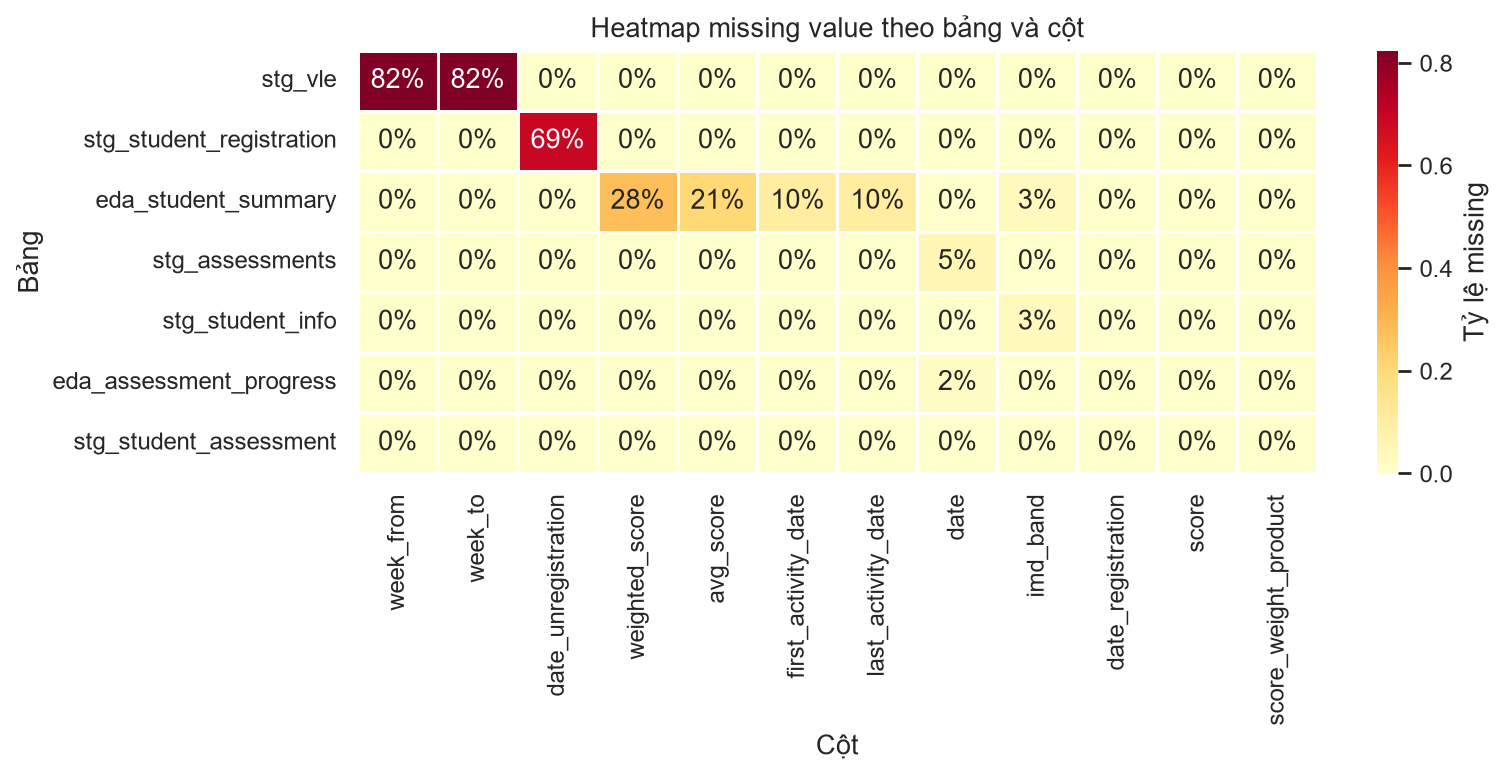

missing_rate_by_table.png


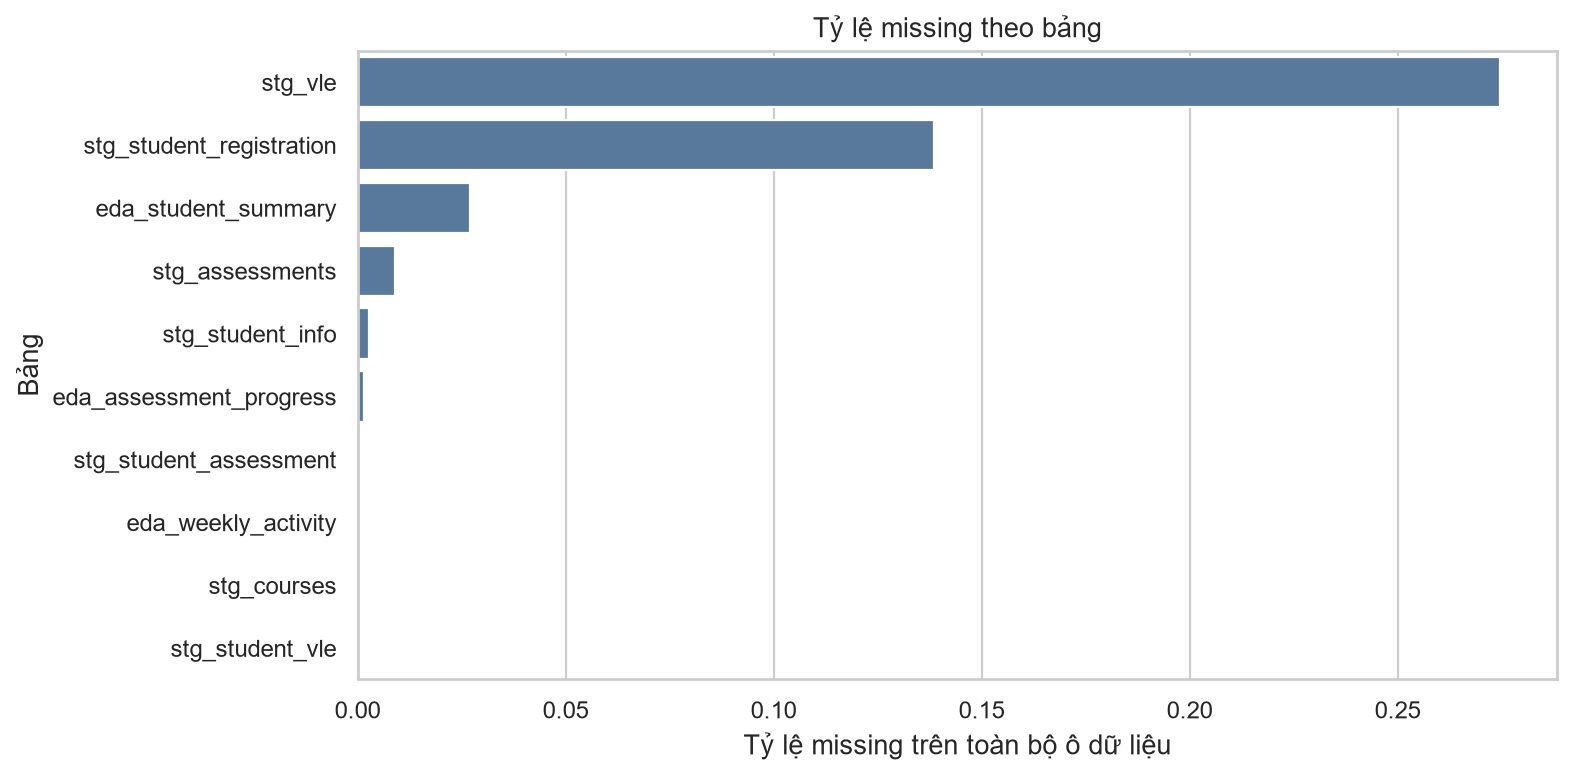

score_missing_by_assessment_type.png


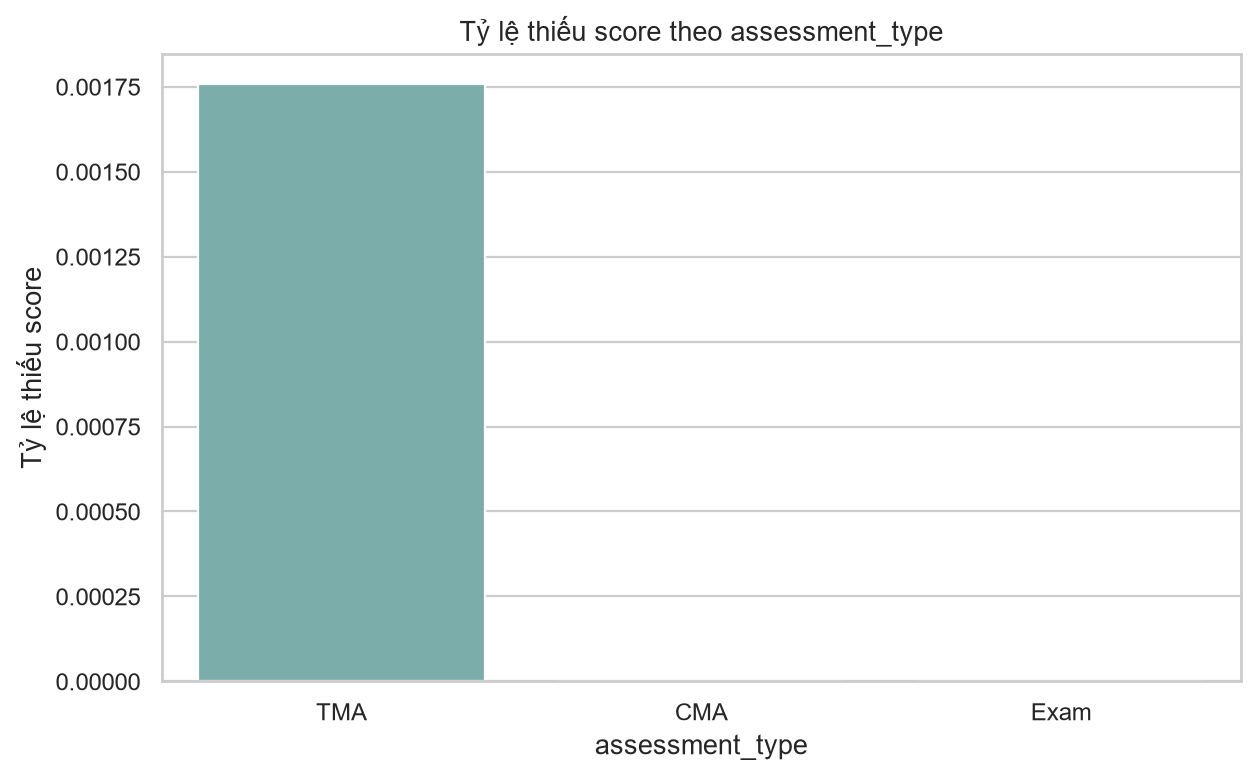

top_missing_columns.png


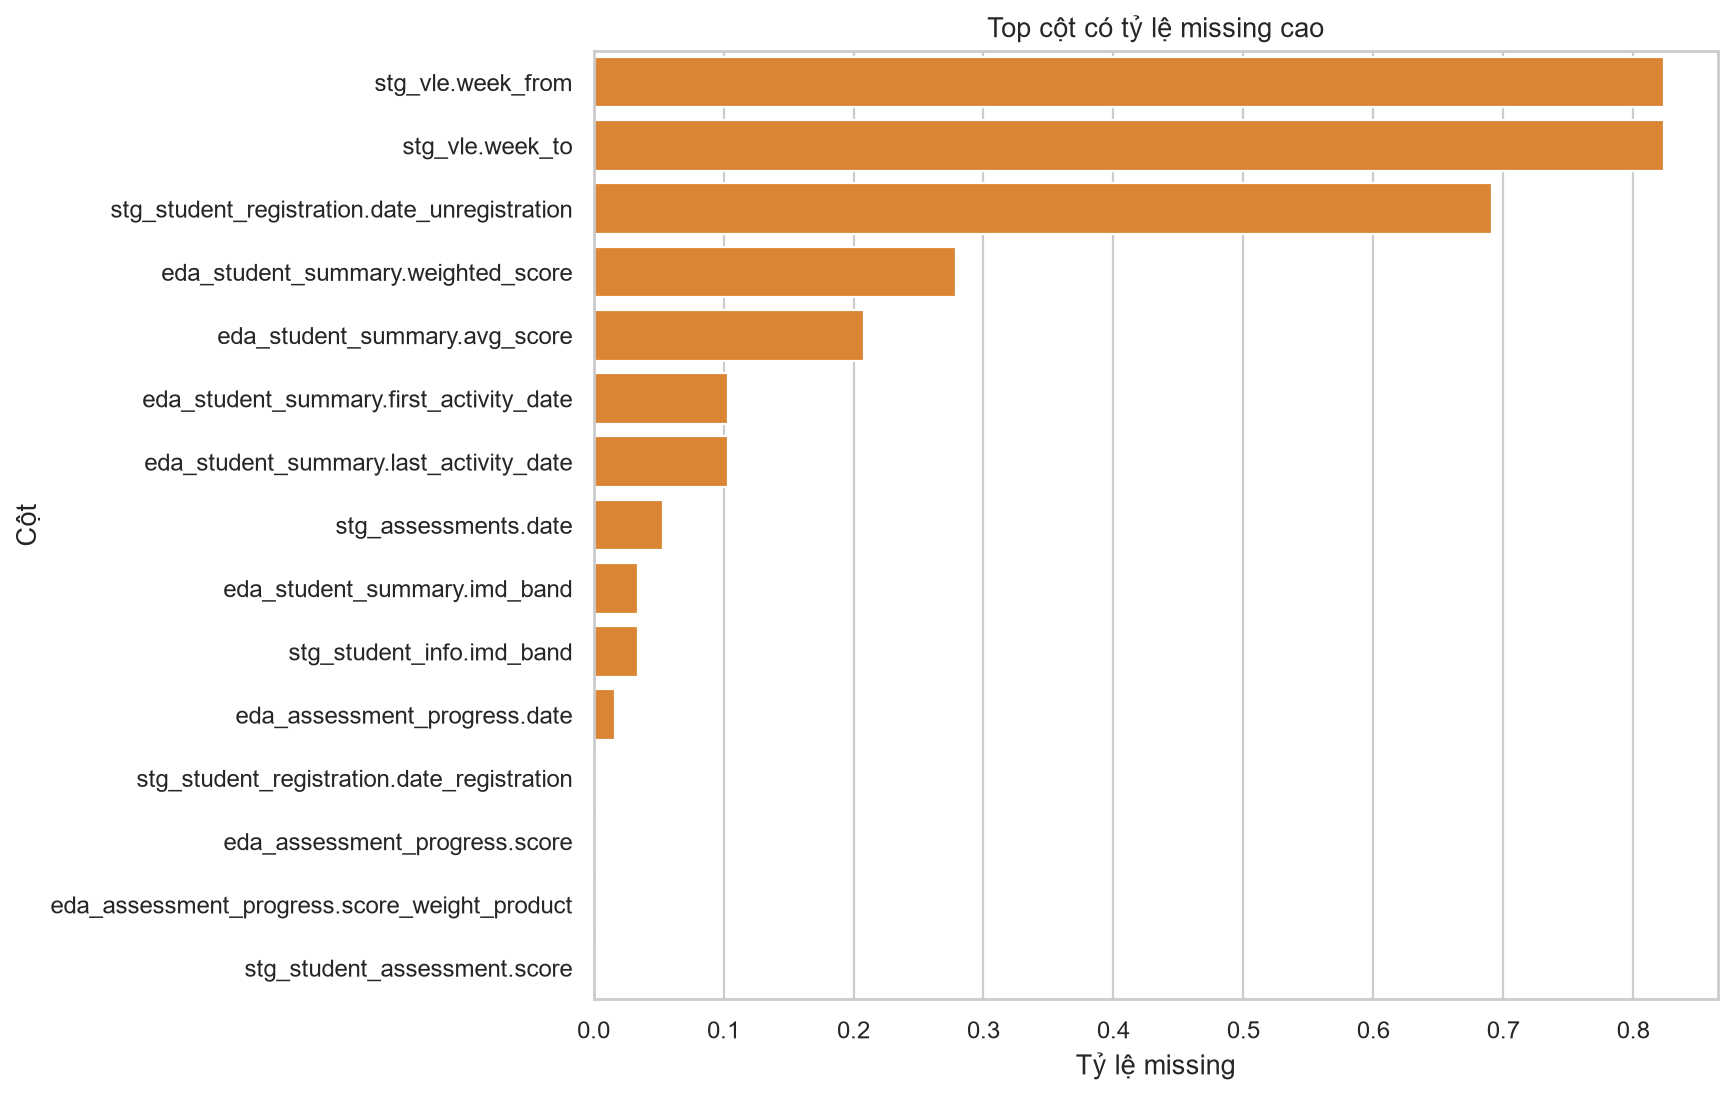

In [5]:
from IPython.display import Image

for figure in sorted(FIGURE_DIR.glob("*.png")):
    print(figure.name)
    display(Image(filename=str(figure)))